决策树数量: 10, 测试精度: 0.7989
决策树数量: 20, 测试精度: 0.8101
决策树数量: 30, 测试精度: 0.8212
决策树数量: 40, 测试精度: 0.8156
决策树数量: 50, 测试精度: 0.8212
决策树数量: 60, 测试精度: 0.8268
决策树数量: 70, 测试精度: 0.8212
决策树数量: 80, 测试精度: 0.8156
决策树数量: 90, 测试精度: 0.8101
决策树数量: 100, 测试精度: 0.8212


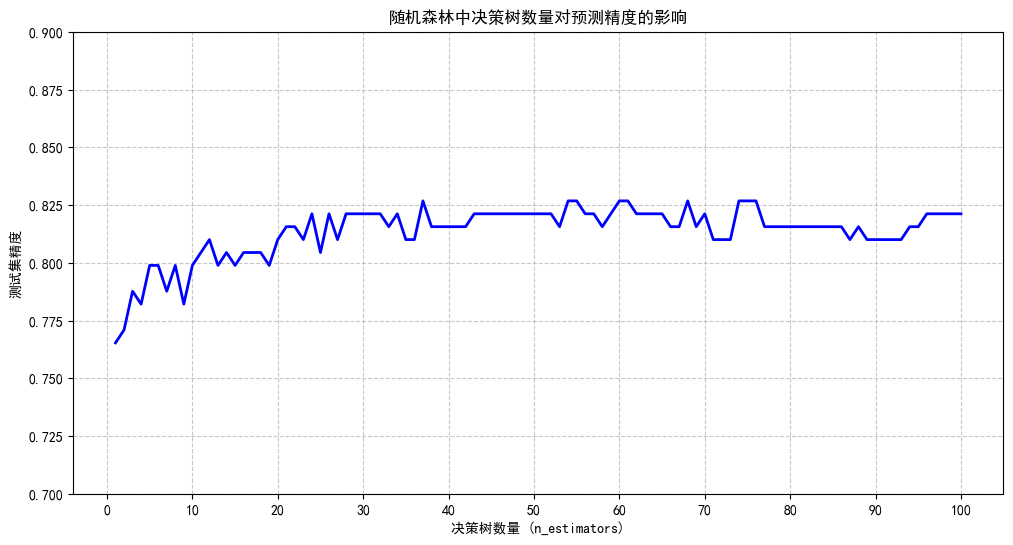


最佳精度: 0.8268 (决策树数量: 37)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# 替换之前的字体设置，只保留系统已有的字体
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]  # 优先使用系统已安装的字体
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

# 1. 加载并预处理数据
data = pd.read_csv('D:/notebook文件/实验1/train.csv')

# 数据预处理：处理缺失值和分类变量（优化版本）
def preprocess_data(df):
    # 创建副本避免修改原数据
    df_copy = df.copy()
    
    # 填充缺失值（不使用inplace，避免警告）
    df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())
    df_copy['Embarked'] = df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0])
    df_copy['Fare'] = df_copy['Fare'].fillna(df_copy['Fare'].median())
    
    # 选择有用的特征
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    X = df_copy[features].copy()  # 显式创建副本
    
    # 将分类变量转换为数值
    le_sex = LabelEncoder()
    le_embarked = LabelEncoder()
    X['Sex'] = le_sex.fit_transform(X['Sex'])
    X['Embarked'] = le_embarked.fit_transform(X['Embarked'])
    
    return X

# 准备特征和目标变量
X = preprocess_data(data)
y = data['Survived']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. 评估不同决策树数量对模型精度的影响
n_estimators_range = range(1, 101)
accuracy_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores.append(accuracy)
    
    if n % 10 == 0:
        print(f"决策树数量: {n}, 测试精度: {accuracy:.4f}")

# 3. 可视化结果
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, accuracy_scores, 'b-', linewidth=2)
plt.xlabel('决策树数量 (n_estimators)')
plt.ylabel('测试集精度')
plt.title('随机森林中决策树数量对预测精度的影响')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, 101, 10))
plt.ylim(0.7, 0.9)
plt.show()

# 输出最佳精度和对应的决策树数量
best_accuracy = max(accuracy_scores)
best_n = n_estimators_range[accuracy_scores.index(best_accuracy)]
print(f"\n最佳精度: {best_accuracy:.4f} (决策树数量: {best_n})")

决策树数量: 10, 验证集精度: 0.7989
决策树数量: 20, 验证集精度: 0.8101
决策树数量: 30, 验证集精度: 0.8212
决策树数量: 40, 验证集精度: 0.8156
决策树数量: 50, 验证集精度: 0.8212
决策树数量: 60, 验证集精度: 0.8268
决策树数量: 70, 验证集精度: 0.8212
决策树数量: 80, 验证集精度: 0.8156
决策树数量: 90, 验证集精度: 0.8101
决策树数量: 100, 验证集精度: 0.8212


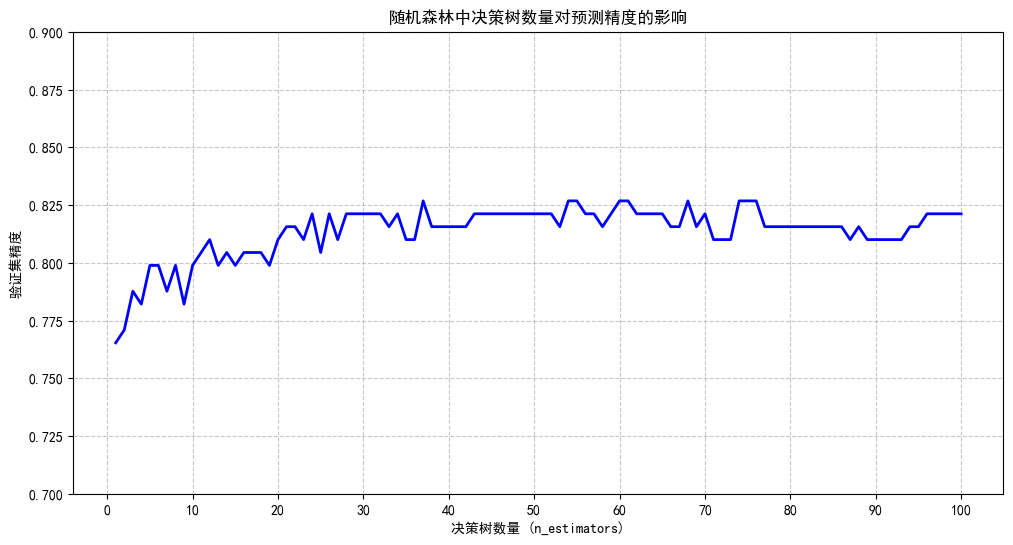


最佳精度: 0.8268 (决策树数量: 37)

预测结果已保存至：D:/notebook文件/实验1/titanic_test_predictions.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# 字体设置（解决中文显示问题）
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 1. 加载数据（训练集+独立测试集）
train_data = pd.read_csv('D:/notebook文件/实验1/train.csv')
test_data = pd.read_csv('D:/notebook文件/实验1/test.csv')  # 加载待预测的test集
test_passenger_ids = test_data['PassengerId']  # 保存乘客ID（后续用于输出结果）

# 2. 数据预处理函数（支持训练集和测试集，避免重复代码）
def preprocess_data(df, is_train=True, le_sex=None, le_embarked=None):
    df_copy = df.copy()
    
    # 填充缺失值
    df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())
    df_copy['Embarked'] = df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0])
    df_copy['Fare'] = df_copy['Fare'].fillna(df_copy['Fare'].median())
    
    # 选择特征
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
    X = df_copy[features].copy()
    
    # 训练集：初始化LabelEncoder并拟合
    if is_train:
        le_sex = LabelEncoder()
        le_embarked = LabelEncoder()
        X['Sex'] = le_sex.fit_transform(X['Sex'])
        X['Embarked'] = le_embarked.fit_transform(X['Embarked'])
        return X, le_sex, le_embarked
    # 测试集：使用训练集拟合好的LabelEncoder（避免数据泄露）
    else:
        X['Sex'] = le_sex.transform(X['Sex'])
        X['Embarked'] = le_embarked.transform(X['Embarked'])
        return X

# 3. 预处理训练集和测试集
X_train_full, le_sex, le_embarked = preprocess_data(train_data, is_train=True)
y_train_full = train_data['Survived']
X_test_predict = preprocess_data(test_data, is_train=False, le_sex=le_sex, le_embarked=le_embarked)

# 4. 划分训练集和验证集（用于评估模型精度）
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

# 5. 评估不同决策树数量对精度的影响
n_estimators_range = range(1, 101)
accuracy_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_val_pred = rf.predict(X_val)
    accuracy = accuracy_score(y_val, y_val_pred)
    accuracy_scores.append(accuracy)
    
    if n % 10 == 0:
        print(f"决策树数量: {n}, 验证集精度: {accuracy:.4f}")

# 6. 可视化精度变化
plt.figure(figsize=(12, 6))
plt.plot(n_estimators_range, accuracy_scores, 'b-', linewidth=2)
plt.xlabel('决策树数量 (n_estimators)')
plt.ylabel('验证集精度')
plt.title('随机森林中决策树数量对预测精度的影响')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(np.arange(0, 101, 10))
plt.ylim(0.7, 0.9)
plt.show()

# 7. 用最佳决策树数量训练最终模型，并预测test集
best_accuracy = max(accuracy_scores)
best_n = n_estimators_range[accuracy_scores.index(best_accuracy)]
print(f"\n最佳精度: {best_accuracy:.4f} (决策树数量: {best_n})")

# 用全量训练集训练最终模型（提升泛化能力）
final_rf = RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)
final_rf.fit(X_train_full, y_train_full)

# 预测test集生存情况
test_survived_pred = final_rf.predict(X_test_predict)

# 8. 保存预测结果（CSV格式，可直接用于Kaggle提交）
result_df = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': test_survived_pred  # 1=存活，0=死亡
})
result_df.to_csv('D:/notebook文件/实验1/titanic_test_predictions.csv', index=False)
print("\n预测结果已保存至：D:/notebook文件/实验1/titanic_test_predictions.csv")